# 누구에게 어떤 프로모션을 제공해야 할까?
### 예산 제약 하의 정책학습(Policy Learning) 기반 프로모션 타겟팅

<small><em>Written by 조해창 · <a href="https://github.com/Funbucket">GitHub</a> · <a href="https://www.linkedin.com/in/hae-chang-cho/">LinkedIn</a></em></small>

## 요약 (Executive Summary)

**문제.** 한 소프트웨어 회사는 고객에게 *기술지원*과 *할인* 두 가지 프로모션을 제공할 수 있습니다(두 개입의 조합으로 총 4가지 처치). 예산은 제한되어 있고, 프로모션 효과는 고객마다 다릅니다. 따라서 핵심 질문은 다음과 같습니다.

> **"제한된 예산 안에서 누구에게 어떤 프로모션을 제공해야 전체 순이익이 가장 커질까?"**

**접근.** 약 2,000곳의 **관찰 데이터**에 정책학습(policy learning)을 적용했습니다. ① 처치 효과의 이질성을 진단하고, ② 관찰 데이터의 인과 식별 가정을 점검한 뒤, ③ 세 가지 정책(DRLearner plug-in · DRPolicyTree · DRPolicyForest)을 학습하고, ④ 학습/평가 데이터를 분리해 **AIPW(doubly robust) score**로 정책 가치를 비교했으며, ⑤ 예산 제약 하의 효율은 **비용 곡선(cost curve)**으로 평가했습니다.

**핵심 결과.**

| | 고객사당 평균 순이익 | 처치 없음 대비 |
| --- | ---: | ---: |
| 처치 없음 (all none) | \$7,249 | — |
| 최선의 단일 처치 (전원 기술지원) | \$10,527 | +45% |
| **고객별 타겟팅 (DRLearner plug-in)** | **\$11,798** | **+63%** |

- 고객별 타겟팅 정책은 가장 좋은 **단일 처치 정책보다 약 12%**, 처치 없음 대비 약 63% 높은 순이익을 냈습니다.
- 처치 배정을 좌우한 핵심 요인은 **직원 수(42%)와 고객 규모(38%)**였습니다. 규모가 큰 고객에게는 *기술지원+할인*을, 그 외 고객에게는 주로 *기술지원*을 배정했습니다.
- **예산 수준에 따라 최적 정책이 달랐습니다.** 소액 예산에서는 평균 비용이 낮은 *전원 기술지원*이 가장 효율적이지만, 예산이 고객사당 \$4,000~6,000 수준으로 커지면 학습 정책이 더 높은 순이익을 냈습니다.

**핵심 제안.** 모두에게 동일한 프로모션을 적용하기보다, **고객 규모·직원 수에 기반한 타겟팅 규칙**을 적용하길 제안합니다. 성능을 최우선한다면 plug-in/forest 정책을, 이해관계자 설명과 운영 안정성이 중요하다면 약간의 성능을 양보하더라도 해석 가능한 **depth=2 의사결정 트리 정책**을 권장합니다(자세한 내용은 마지막 "결론 및 제언" 절 참조).

## 1. 비즈니스 문제

인과추론의 많은 문제는 평균 처치 효과(ATE)에 집중합니다. "프로모션을 진행할 것인가, 하지 않을 것인가?"라는 질문은 **모든 고객에게 동일한** 프로모션을 제공하는 정책과 아무에게도 제공하지 않는 정책을 비교하는 문제입니다.

하지만 예산이 제한되어 있고 그 안에서 최대 효과를 내야 한다면 이야기가 달라집니다. 프로모션 효과가 고객마다 다르다면, 모두에게 동일하게 제공하는 전략이 최선이 아닐 수 있습니다.

- 마케팅 유무와 상관없이 어차피 구매하거나(*always-converters*), 반대로 아무리 혜택을 줘도 사지 않을 고객(*lost causes*)에게 불필요한 예산을 낭비하게 됩니다.
- 마케팅에 부정적으로 반응하는 고객(*sleeping dogs*) 때문에 오히려 손실이 발생하며,
- 정작 효과가 클 고객(*high-responders*)을 우선순위에 두지 못해 잠재 매출을 놓칩니다.

따라서 이 분석이 답하려는 질문은 다음과 같습니다.

> _"어떤 고객을 대상으로 해야 순이익이 가장 커질까?"_

가능한 처치 규칙들을 탐색해 전체 평균 순수익을 근사적으로 최대화하는 문제, 즉 **"누구를 처치해야 하는가?"**에 답하는 문제를 다룹니다. 이를 **정책학습(policy learning)**이라고 부릅니다.

이 분석은 다음 다섯 가지 질문으로 구성됩니다.

1. **Q1.** 프로모션 효과는 정말 고객마다 다른가? (이질성 진단)
2. **Q2.** 관찰 데이터로 인과 효과를 신뢰할 수 있는가? (식별 가정)
3. **Q3.** 누구에게 무엇을 배정해야 하는가? (정책학습)
4. **Q4.** 학습한 정책이 정말 더 나은가? (정책 평가)
5. **Q5.** 예산이 제한되면 어떤 정책이 유리한가? (예산 제약)

<img src="./assets/AJStyles&Undertaker.jpg" width="480"/>

<small>같은 자극(프로모션)에도 사람마다 반응이 다릅니다. 정책학습은 "누구에게 효과가 큰가"를 데이터로 찾습니다.</small>

In [1]:
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

from econml.dr import DRLearner
from econml.policy import DRPolicyForest, DRPolicyTree

warnings.filterwarnings('ignore')

# 리포트(PDF)용 그림 저장 경로
FIGDIR = Path('figures')
FIGDIR.mkdir(exist_ok=True)
SAVE_KW = dict(dpi=150, bbox_inches='tight')

SEED = 1
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid')


## 2. 데이터와 처치 정의

한 소프트웨어 판매 회사는 할인이나 기술지원 같은 프로모션이 고객의 소프트웨어 구매를 실제로 늘리는지, 그리고 어떤 고객에게 더 효과적인지 알고 싶어합니다.

고객마다 서로 다른 프로모션을 무작위로 배정하는 실험(RCT)이 가장 이상적이지만, 실제 비즈니스 환경에서는 비용 문제, 영업 전략, 대형 고객을 놓칠 위험 등으로 무작위 실험을 수행하기 어렵습니다. 따라서 이번 데이터는 무작위 실험 데이터가 아닌 **관찰 데이터**입니다.

데이터에는 약 2,000곳의 고객 정보가 포함되며, 다음과 같은 변수들로 구성됩니다.

- **고객 특성:** 산업 분야, 규모, 매출, 기술 프로필
- **개입:** 고객에게 제공된 프로모션
- **결과:** 프로모션 제공 이후 1년 동안의 소프트웨어 구매 금액

| 변수명 | 타입 | 설명 |
| --- | -- | --- |
| Global Flag | X | 글로벌 오피스(해외 지사) 보유 여부 |
| Major Flag | X | 해당 산업의 대규모 소비 고객 여부 |
| SMC Flag | X | 중소기업(SMC) 여부 |
| Commercial Flag | X | 사업 유형이 상업용인지 여부 |
| IT Spend | X | IT 관련 구매 금액 |
| Employee Count | X | 직원 수 |
| PC Count | X | 사용 PC 수 |
| Size | X | 연간 총매출 기준 고객 규모 |
| Tech Support | T | 기술지원 제공 여부 (이진값) |
| Discount | T | 할인 제공 여부 (이진값) |
| Revenue | Y | 소프트웨어 구매 금액 기준 매출 |

`Tech Support`와 `Discount`는 모두 개입이므로, 이를 조합해 네 가지 처치로 정의합니다.

$$A_i \in \{0, 1, 2, 3\}$$

- $A_i = 0$: 아무 개입도 제공하지 않음 (none)
- $A_i = 1$: 기술지원만 제공 (tech_support_only)
- $A_i = 2$: 할인만 제공 (discount_only)
- $A_i = 3$: 기술지원과 할인을 모두 제공 (discount_plus_support)

In [2]:
data = pd.read_csv('./data/multi_attribution_sample.csv')
data.columns = data.columns.str.strip()

covariates = [
    'Global Flag',
    'Major Flag',
    'SMC Flag',
    'Commercial Flag',
    'IT Spend',
    'Employee Count',
    'PC Count',
    'Size',
]
outcome = 'Revenue'

TREATMENT_NAMES = {
    0: 'none',
    1: 'tech_support_only',
    2: 'discount_only',
    3: 'discount_plus_support',
}
TREATMENT_LABELS = [TREATMENT_NAMES[i] for i in range(4)]

required_columns = covariates + ['Tech Support', 'Discount', outcome]
for col in required_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

policy_df = data[required_columns].dropna().copy()
policy_df['treatment'] = (
    2 * policy_df['Discount'].astype(int)
    + policy_df['Tech Support'].astype(int)
).astype(int)
policy_df['treatment_name'] = policy_df['treatment'].map(TREATMENT_NAMES)

n = len(policy_df)
X = policy_df[covariates].to_numpy()
Y = policy_df[outcome].to_numpy(dtype=float)
A = policy_df['treatment'].to_numpy(dtype=int)

print(policy_df.shape)
policy_df.head()


(2000, 13)


,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,treatment,treatment_name
0,1,0,1,0,45537,26,26,152205,0,1,17688.36300,2,discount_only
1,0,0,1,1,20842,107,70,159038,0,1,14981.43559,2,discount_only
2,0,0,0,1,82171,10,7,264935,1,1,32917.13894,3,discount_plus_support
3,0,0,0,0,30288,40,39,77522,1,1,14773.76855,3,discount_plus_support
4,0,0,1,0,25930,37,43,91446,1,1,17098.69823,3,discount_plus_support


### 2.1. 비용 설정

수익 극대화를 위해서는 매출과 함께 **비용**도 고려해야 합니다. 또한 동일한 프로모션이라도 고객 특성에 따라 비용이 달라질 수 있습니다. 예를 들어 기술지원은 직원 수가 많은 기업일수록 더 많은 지원 시간이 필요하고, 할인은 규모가 큰 고객일수록 더 큰 할인 폭을 요구할 수 있습니다.

이 데이터에는 실제 비용 정보가 없으므로, 고객 특성에 따라 달라지는 비용을 **시뮬레이션**해 사용합니다. 기술지원 비용은 직원 수가 많을수록, 할인 비용은 고객 규모가 클수록 증가하도록 설정합니다. 로그정규분포를 사용해 비용이 항상 양수이고 일부 고객에서 큰 비용이 발생하는 분포를 반영합니다.

$$C_i(\text{tech}) \sim \text{LogNormal}(\log C_{\text{tech}} + 0.5 \cdot \tilde{e}_i,\ 0.3), \qquad C_i(\text{disc}) \sim \text{LogNormal}(\log C_{\text{disc}} + 0.4 \cdot \tilde{s}_i,\ 0.3)$$

여기서 $\tilde{e}_i$는 표준화된 직원 수, $\tilde{s}_i$는 표준화된 회사 규모입니다. 고객별 비용을 반영한 최종 **순이익(net outcome)**은 다음과 같습니다.

$$Y_i^{net} = Y_i - C_i(A_i)$$

이렇게 하면 이후 AIPW score가 순이익 기준으로 계산되어, 비용을 고려한 정책 최적화와 평가가 가능해집니다.

In [3]:
COST_TECH_SUPPORT = 4_000.0   # 기술지원 기본 비용
COST_DISCOUNT     = 5_000.0   # 할인 기본 비용


rng_c = np.random.default_rng(SEED + 99)
emp_idx  = covariates.index('Employee Count')
size_idx = covariates.index('Size')

emp_z  = (X[:, emp_idx]  - X[:, emp_idx].mean())  / (X[:, emp_idx].std()  + 1e-8)
size_z = (X[:, size_idx] - X[:, size_idx].mean()) / (X[:, size_idx].std() + 1e-8)

c_tech = rng_c.lognormal(mean=np.log(COST_TECH_SUPPORT) + 0.5 * emp_z, sigma=0.3)
c_disc = rng_c.lognormal(mean=np.log(COST_DISCOUNT) + 0.4 * size_z, sigma=0.3)

c_tech = np.clip(c_tech, 200.0, 40_000.0)
c_disc = np.clip(c_disc, 200.0, 30_000.0)

C_obs = np.select(
    [A == 1, A == 2, A == 3],
    [c_tech, c_disc, c_tech + c_disc],
    default=0.0,
)

Y_net = Y - C_obs

pd.DataFrame({
    'treatment': TREATMENT_LABELS,
    'mean_cost':  [C_obs[A == a].mean() if (A == a).sum() > 0 else 0.0 for a in range(4)],
    'std_cost':   [C_obs[A == a].std()  if (A == a).sum() > 0 else 0.0 for a in range(4)],
    'mean_revenue':     [Y[A == a].mean()     for a in range(4)],
    'mean_net_revenue': [Y_net[A == a].mean() for a in range(4)],
})


,treatment,mean_cost,std_cost,mean_revenue,mean_net_revenue
0,none,0.000000,0.000000,6585.891792,6585.891792
1,tech_support_only,5037.815894,4917.641358,15104.111534,10066.295640
2,discount_only,5181.570334,3043.343172,12247.935953,7066.365619
3,discount_plus_support,12665.283296,7375.490125,26784.124649,14118.841353


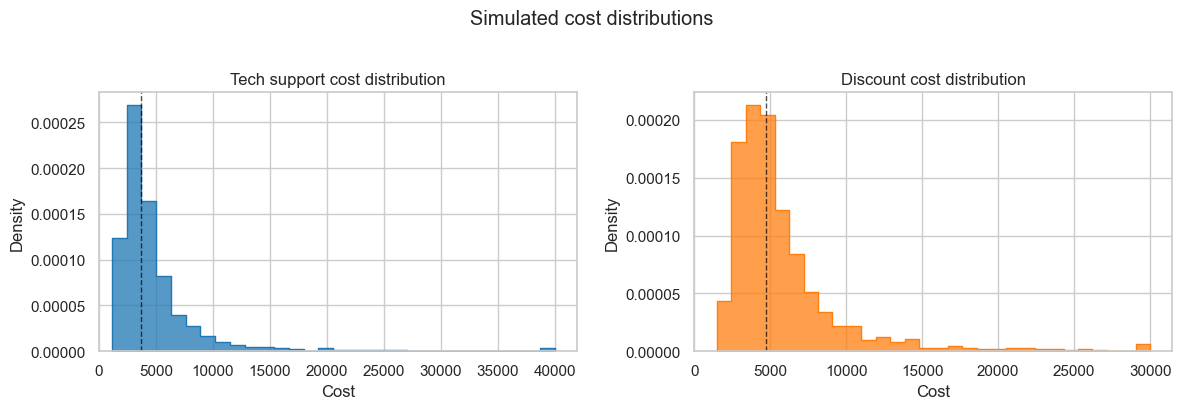

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(c_tech, bins=30, stat='density', element='step', fill=True, ax=axes[0], color='tab:blue')
axes[0].axvline(np.median(c_tech), color='black', ls='--', lw=1, alpha=0.7)
axes[0].set_title('Tech support cost distribution')
axes[0].set_xlabel('Cost')
axes[0].set_ylabel('Density')
axes[0].set_xlim(left=0)

sns.histplot(c_disc, bins=30, stat='density', element='step', fill=True, ax=axes[1], color='tab:orange')
axes[1].axvline(np.median(c_disc), color='black', ls='--', lw=1, alpha=0.7)
axes[1].set_title('Discount cost distribution')
axes[1].set_xlabel('Cost')
axes[1].set_ylabel('Density')
axes[1].set_xlim(left=0)

plt.suptitle('Simulated cost distributions', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig01_cost_dist.png', **SAVE_KW)
plt.show()


### 2.2. 데이터 분할

정책학습과 평가를 같은 데이터로 수행하면 과대추정이 발생할 수 있습니다. 따라서 데이터를 train/test로 나눠 **학습과 평가를 분리**합니다.

In [5]:
idx = np.arange(len(policy_df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.5,
    stratify=A,
    random_state=SEED,
)

X_train = X[train_idx]
X_test = X[test_idx]
A_train = A[train_idx]
A_test = A[test_idx]
Y_net_train = Y_net[train_idx]
Y_net_test = Y_net[test_idx]

print(f"Train: {len(train_idx)} \nTest: {len(test_idx)}")


Train: 1000 
Test: 1000


## Q1. 프로모션 효과는 정말 고객마다 다른가?

타겟팅이 의미가 있으려면, 먼저 **처치 효과가 고객마다 다르다**는 신호가 있어야 합니다. 네 가지 처치 조합($A \in \{0,1,2,3\}$)에 대해 데이터 구조를 점검합니다.

1. 처치별 표본 수 — 각 처치에 충분한 관측치가 있는가?
2. 처치별 고객 특성 평균 — 어떤 고객군이 특정 처치를 받는 경향이 있는가?
3. 처치별 Revenue 분포 — 규모·분산·이상치가 처치마다 어떻게 다른가?

In [6]:
treatment_counts = policy_df['treatment_name'].value_counts().reindex(TREATMENT_LABELS).rename_axis('treatment').to_frame('count')
treatment_counts['share'] = treatment_counts['count'] / len(policy_df)

display(treatment_counts)


,count,share
treatment,,
none,517,0.2585
tech_support_only,462,0.2310
discount_only,477,0.2385
discount_plus_support,544,0.2720


표본 수는 `none` 517곳, `tech_support_only` 462곳, `discount_only` 477곳, `discount_plus_support` 544곳입니다. 각 처치 비중이 23~27%로 비교적 고르게 분포해, 특정 처치에 표본이 극단적으로 부족한 문제는 없습니다. 네 가지 처치를 비교하는 정책학습을 진행하기에 안정적인 분포입니다.

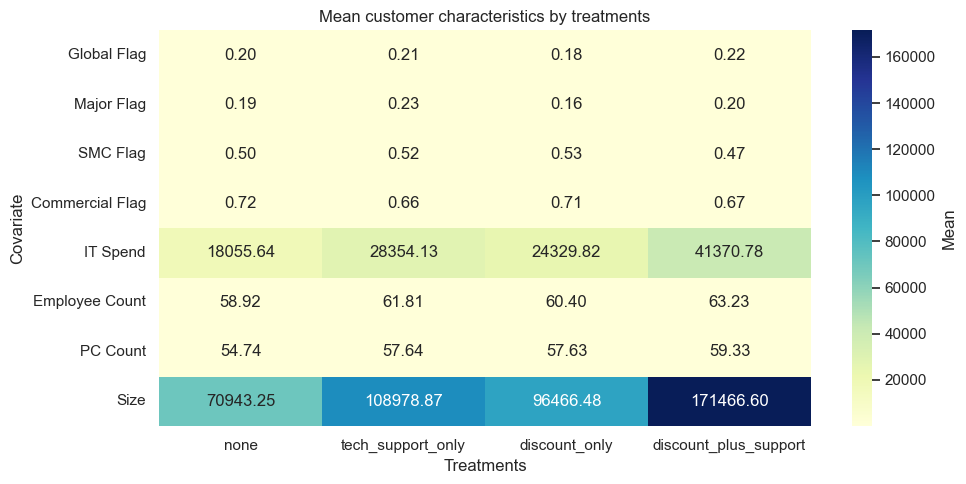

In [7]:
treatment_covariate_means = (
    policy_df
    .groupby('treatment_name')[covariates]
    .mean()
    .reindex(TREATMENT_LABELS)
)

plt.figure(figsize=(10, 5))
sns.heatmap(treatment_covariate_means.T, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean'})
plt.xlabel('Treatments')
plt.ylabel('Covariate')
plt.title('Mean customer characteristics by treatments')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig02_covariate_means.png', **SAVE_KW)
plt.show()


처치별 고객 특성은 동일하지 않습니다. 특히 `Size`와 `IT Spend`의 평균이 처치 그룹별로 다르고, `discount_plus_support` 그룹에 큰 고객이 더 많이 포함되어 있습니다. 도메인적으로도 고객 규모나 IT 지출 수준에 따라 필요한 지원 형태가 달라질 수 있습니다.

이런 차이는 **처치 효과가 고객 특성에 따라 달라질 가능성**을 시사합니다. 동시에 처치 배정이 고객 특성과 얽혀 있다는 뜻이므로, 이후 정책 학습·평가는 이 차이를 보정할 수 있는 **AIPW**를 사용합니다.

,treatment,treatment_name,count,mean,median,std,min,max
0,0,none,517,6585.891792,6123.187067,3363.163462,-616.572451,21445.05937
1,1,tech_support_only,462,15104.111534,14483.719320,5400.319858,4619.491361,40166.67407
2,2,discount_only,477,12247.935953,10454.932500,7472.178476,889.975653,41818.39213
3,3,discount_plus_support,544,26784.124649,23560.252890,13124.968083,5903.906880,86006.92445


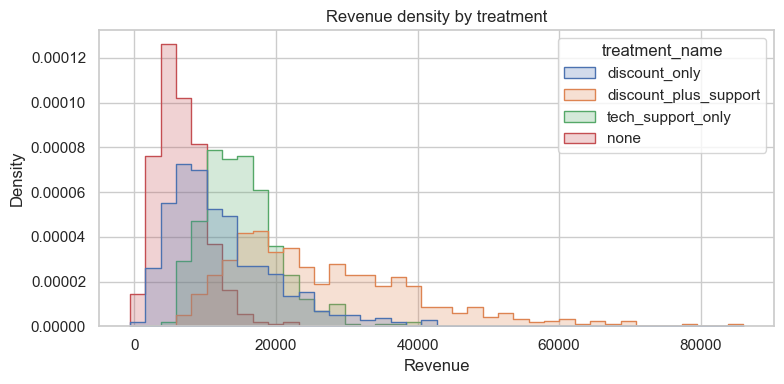

In [8]:
treatment_revenue = (
    policy_df
    .groupby(['treatment', 'treatment_name'])[outcome]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)
display(treatment_revenue)

plt.figure(figsize=(8, 4))

sns.histplot(
    data=policy_df,
    x=outcome,
    hue='treatment_name',
    bins=40,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Revenue density by treatment')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig03_revenue_dist.png', **SAVE_KW)
plt.show()


Revenue 평균은 `none` 약 6,586, `discount_only` 약 12,248, `tech_support_only` 약 15,104, `discount_plus_support` 약 26,784입니다.

다만 규모가 큰 고객일수록 더 강한 개입을 받는 경향이 있으므로, **이 평균 차이를 그대로 처치 효과로 해석하면 안 됩니다.** Revenue 차이에는 고객 특성의 영향과 실제 처치 효과가 함께 섞여 있습니다. 이 교란을 어떻게 분리할 것인가가 바로 Q2의 주제입니다.

> **Q1 요약.** 처치 그룹 간 고객 특성과 결과 분포가 뚜렷이 다릅니다. 이는 (a) 처치 효과가 고객마다 다를 가능성과 (b) 처치 배정이 고객 특성에 의해 교란되어 있음을 동시에 시사합니다. 따라서 단순 평균 비교가 아니라 교란을 보정하는 인과적 접근이 필요합니다.

## Q2. 관찰 데이터로 인과 효과를 신뢰할 수 있는가?

관찰 데이터에서 AIPW 추정이 인과적으로 유효하려면 두 가지 가정이 필요합니다.

**1. Unconfoundedness (비교란성)**

$$\{Y_i(0), Y_i(1), Y_i(2), Y_i(3)\} \perp A_i \mid X_i$$

관측된 공변량 $X_i$를 조건부로 했을 때, 처치 배정이 잠재 결과와 독립이어야 합니다. 즉, 고객 규모·IT 지출·직원 수 등이 처치 배정을 충분히 설명한다고 가정합니다.

**2. Positivity (양수성)**

$$P(A_i = a \mid X_i = x) > 0 \quad \forall a \in \{0,1,2,3\},\ \forall x$$

모든 고객 특성 범위에서 각 처치가 어느 정도 관측되어야 합니다.

이 중 Positivity는 propensity score를 추정해 직접 확인할 수 있습니다.

$$e_a(x) = P(A_i = a \mid X_i = x)$$

추가로 propensity score가 극단적으로 치우쳐 있지 않은지도 확인합니다. 특정 고객군에서 어떤 처치의 $e_a(x)$가 0에 매우 가까우면, 일부 관측치에 지나치게 큰 가중치가 부여되어 추정이 불안정해질 수 있습니다.

In [9]:
multi_propensity = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=20,
    random_state=SEED,
    n_jobs=1,
)
multi_propensity.fit(X_train, A_train)
e_hat_raw = multi_propensity.predict_proba(X_test)

propensity_summary = pd.DataFrame({
    'treatment': TREATMENT_LABELS,
    'mean_propensity': e_hat_raw.mean(axis=0),
    'min_propensity': e_hat_raw.min(axis=0),
    'p01_propensity': np.quantile(e_hat_raw, 0.01, axis=0),
    'propensity_below_0_05_rate': (e_hat_raw < 0.05).mean(axis=0),
})
display(propensity_summary)


,treatment,mean_propensity,min_propensity,p01_propensity,propensity_below_0_05_rate
0,none,0.263941,0.057600,0.066831,0.0
1,tech_support_only,0.229863,0.126582,0.156283,0.0
2,discount_only,0.237934,0.125638,0.141322,0.0
3,discount_plus_support,0.268263,0.087299,0.101304,0.0


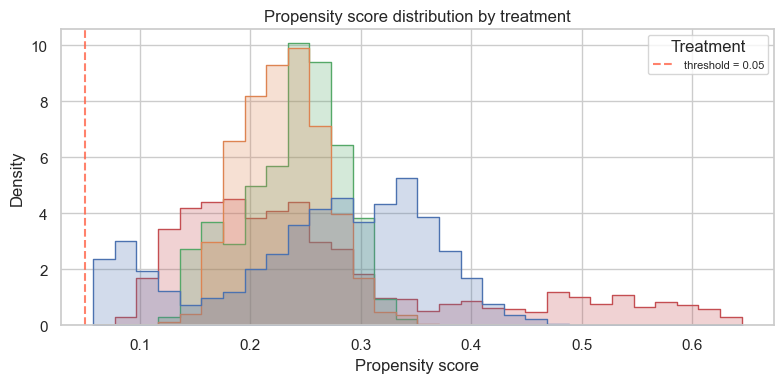

In [10]:
prop_df = pd.DataFrame(e_hat_raw, columns=TREATMENT_LABELS)
prop_long = prop_df.melt(var_name='treatment', value_name='propensity')

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=prop_long, x='propensity', hue='treatment',
    bins=30, element='step', stat='density', common_norm=False, ax=ax,
)

ax.axvline(0.05, color='tomato', lw=1.5, ls='--', alpha=0.8, label='threshold = 0.05')
ax.legend(title='Treatment', fontsize=8)
ax.set_xlabel('Propensity score')
ax.set_ylabel('Density')
ax.set_title('Propensity score distribution by treatment')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig04_propensity.png', **SAVE_KW)
plt.show()


이 데이터에서 $\hat e_a(X_i)$의 최솟값은 약 **0.058**이며, `e_hat < 0.05`인 경우도 관측되지 않았습니다. 즉, 극단적으로 작은 propensity score로 일부 관측치에 과도한 가중치가 부여되는 문제는 크지 않습니다. 그래프에서도 네 처치의 propensity 분포가 전반적으로 잘 겹쳐, 뚜렷한 positivity 위반은 보이지 않습니다.

> **Q2 요약.** Positivity는 데이터로 확인되어 충족됩니다. Unconfoundedness는 검정 불가능한 가정이지만, 고객 규모·직원 수·IT 지출 등 처치 배정을 설명할 핵심 변수들이 관측되어 있어 합리적인 가정으로 받아들입니다. 따라서 이후 분석은 outcome model과 propensity model을 함께 쓰는 **doubly robust(AIPW)** 추정을 채택합니다.

## Q3. 누구에게 무엇을 배정해야 하는가?

이제 본격적으로 정책을 학습합니다. 세 가지 방법을 비교합니다.

- **Plug-in Policy (DRLearner):** 고객별 CATE를 추정한 뒤 기대 순이익이 가장 큰 처치를 선택. 유연하지만 CATE 추정 품질에 민감.
- **DRPolicyTree:** AIPW score를 직접 최대화하되 정책을 얕은 의사결정 트리로 제한 → **해석 가능**.
- **DRPolicyForest:** AIPW score를 직접 최대화하되 forest를 사용 → 분산이 작고 안정적이지만 해석은 어려움.

세 정책 모두 train set에서 학습하고, 동일한 test set에서 가치를 비교합니다(Q4).

### Q3.1. Plug-in Policy

Plug-in policy는 먼저 고객별 처치 효과(CATE)를 추정한 뒤 그 값으로 정책을 만듭니다. 여러 처치가 있으므로 `none`을 baseline으로 두고 `DRLearner`로 상대효과를 추정합니다.

$$\hat\tau_a(x) = \widehat{\mathbb{E}}[Y^{net}(a) - Y^{net}(0) \mid X=x], \qquad a \in \{1,2,3\}$$

baseline의 상대효과는 0이므로 고객별로 $[0, \hat\tau_1(x), \hat\tau_2(x), \hat\tau_3(x)]$를 비교해 가장 큰 처치를 선택합니다.

$$\hat\pi_{plugin}(x) = \arg\max_{a \in \{0,1,2,3\}} \widehat{\mathbb{E}}[Y^{net}(a) - Y^{net}(0) \mid X=x]$$

> **NOTE.** "각 고객의 AIPW score $\hat\Gamma_{i,a}$ 중 가장 큰 처치를 고르면 되지 않나?"라고 생각할 수 있습니다. 그러나 AIPW score는 개별 관측치 수준에서 분산이 매우 커서, pointwise argmax 정책은 노이즈에 과적합됩니다. AIPW score는 반드시 **집계된 형태**로 사용해야 합니다(정책 가치 추정, 노드 단위 평균 최적화, pseudo-outcome 회귀 등).

In [11]:
dr_cate = DRLearner(
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_final=RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
)
dr_cate.fit(Y_net_train, A_train, X=X_train)

# 처치 없음을 기준선으로 두고, 나머지 처치별 E[Y_net(a) - Y_net(0) | X]를 반환
cate_vs_none = dr_cate.const_marginal_effect(X_test)
plugin_treatment_values = np.column_stack([
    np.zeros(len(X_test)),  # 처치 없음: 기준선이므로 상대효과 = 0
    cate_vs_none,
])
pi_plugin = np.argmax(plugin_treatment_values, axis=1)


In [12]:
pd.Series(pi_plugin).map(TREATMENT_NAMES).value_counts(normalize=True).reindex(TREATMENT_LABELS).fillna(0)


none                     0.092
tech_support_only        0.499
discount_only            0.035
discount_plus_support    0.374
Name: proportion, dtype: float64

In [13]:
none_idx = np.where(pi_plugin == 0)[0][:3]
tech_idx = np.where(pi_plugin == 1)[0][:3]
both_idx = np.where(pi_plugin == 3)[0][:3]
sample_ids = np.concatenate([none_idx, tech_idx, both_idx])

df_plugin_sample = pd.DataFrame(X_test[sample_ids], columns=covariates)[['Size', 'Employee Count', 'IT Spend']]
df_plugin_sample['assigned_treatment'] = pd.Series(pi_plugin[sample_ids]).map(TREATMENT_NAMES).values
df_plugin_sample[['tau_tech', 'tau_disc', 'tau_both']] = np.round(cate_vs_none[sample_ids], 0).astype(int)
df_plugin_sample.index = pd.RangeIndex(len(df_plugin_sample))
df_plugin_sample


,Size,Employee Count,IT Spend,assigned_treatment,tau_tech,tau_disc,tau_both
0,96204,142,17655,none,-6140,-1419,-1715
1,25390,178,7971,none,-14556,-4252,-7277
2,66555,279,19899,none,-17629,-2896,-16555
3,70868,20,26263,tech_support_only,4265,-41,4146
4,24152,18,4610,tech_support_only,4174,-2315,-772
5,54855,63,14772,tech_support_only,2061,-698,587
6,399228,36,133052,discount_plus_support,7849,-1278,11819
7,181704,24,59529,discount_plus_support,9171,5221,10249
8,294377,37,112485,discount_plus_support,7124,877,9048


plug-in 정책은 약 50%에게 `tech_support_only`, 37%에게 `discount_plus_support`, 약 9%에게 `none`을 배정합니다. 비용을 함께 고려하면서, 기대 순이익이 음수로 예상되는 일부 고객에게는 처치를 하지 않는 선택이 나타납니다.

### Q3.2. Policy Tree

현업에서는 성능뿐 아니라 **정책의 설명 가능성**도 중요합니다. 얕은 의사결정 트리 기반 정책이 실무에서 자주 쓰이는 이유는 다음과 같습니다.

- **이해관계자 설명:** 직관적인 분기 규칙이라 정책을 쉽게 설명·공유할 수 있습니다.
- **공정성 검토:** 어떤 고객이 어떤 처치를 받는지 구조가 명확해 편향 점검이 쉽습니다.
- **운영 안정성:** 단순한 규칙 기반 정책이 운영·관리 측면에서 안정적입니다.

이 경우 정책을 모든 가능한 함수에서 찾는 대신, 제한된 정책 클래스 $\Pi$ 안에서 탐색합니다.

$$\hat\pi = \arg\max_{\pi \in \Pi} \frac{1}{n}\sum_{i=1}^{n} \widehat\Gamma_{i,\pi(X_i)}$$

`econml`의 `DRPolicyTree`를 사용하며, leaf가 지나치게 작아지면 다중 처치 환경에서 value 추정이 불안정해지므로 `min_samples_leaf`로 이를 방지합니다.

In [14]:
dr_policy_tree = DRPolicyTree(
    max_depth=2,
    min_samples_leaf=30,
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
)
dr_policy_tree.fit(Y_net_train, A_train, X=X_train)
pi_tree = dr_policy_tree.predict(X_test).astype(int).ravel()

pd.Series(pi_tree).map(TREATMENT_NAMES).value_counts(normalize=True).reindex(TREATMENT_LABELS).fillna(0)


none                     0.199
tech_support_only        0.475
discount_only            0.000
discount_plus_support    0.326
Name: proportion, dtype: float64

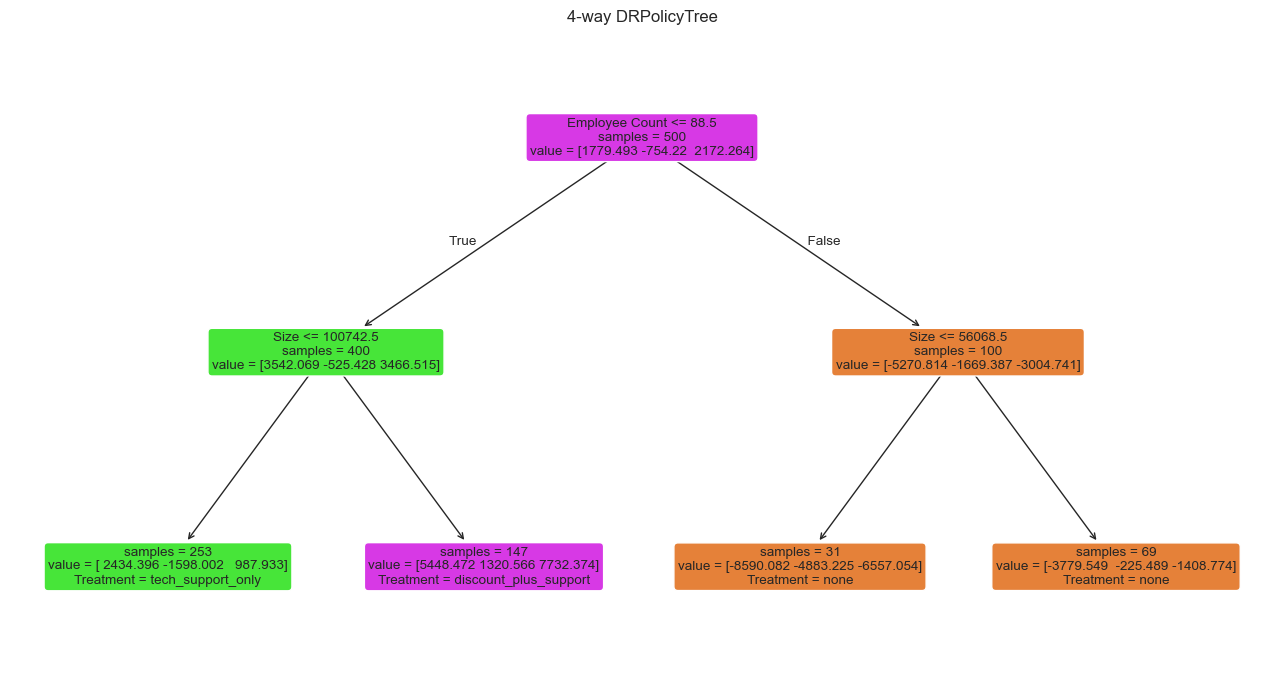

In [15]:
fig, ax = plt.subplots(figsize=(13, 7))
dr_policy_tree.plot(feature_names=covariates, treatment_names=TREATMENT_LABELS, ax=ax)
ax.set_title('4-way DRPolicyTree')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig05_policy_tree.png', **SAVE_KW)
plt.show()


이 트리 정책은 주로 `Size`를 기준으로 고객을 나눕니다. 약 20%의 고객에게는 `none`을 배정하는데, 비용을 반영한 결과 일부 고객은 처치 시 기대 순이익이 낮아 처치하지 않는 편이 낫다고 판단한 것입니다. 전체적으로 규모가 큰 고객에게 `discount_plus_support`를, 그 외에는 주로 `tech_support_only`를 배정합니다.

### Q3.3. Policy Forest

Policy Forest 역시 AIPW score를 직접 최대화하지만, 단일 tree 대신 여러 tree의 결과를 평균해 **분산이 작고** 복잡한 이질성을 더 안정적으로 학습합니다. 대신 하나의 명확한 의사결정 규칙으로 해석하기는 어렵습니다. `econml`의 `DRPolicyForest`를 사용합니다.

In [16]:
dr_policy_forest = DRPolicyForest(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=30,
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
    n_jobs=1,
)
dr_policy_forest.fit(Y_net_train, A_train, X=X_train)
pi_forest = dr_policy_forest.predict(X_test).astype(int).ravel()

pd.Series(pi_forest).map(TREATMENT_NAMES).value_counts(normalize=True).reindex(TREATMENT_LABELS).fillna(0)


none                     0.114
tech_support_only        0.469
discount_only            0.000
discount_plus_support    0.417
Name: proportion, dtype: float64

DRPolicyForest는 전반적으로 plug-in 정책과 유사한 배정을 보입니다. `none` 11%, `tech_support_only` 47%, `discount_plus_support` 42%로, plug-in보다 `discount_plus_support` 비중이 조금 더 높습니다.

### Q3.4. 어떤 고객 특성이 배정을 좌우하는가?

DRPolicyForest는 단일 트리 구조가 없어 분기 규칙으로 직접 해석하기 어렵지만, `feature_importances_`로 **어떤 고객 특성이 처치 배정을 주도하는지** 파악할 수 있습니다. 이 값은 각 특성이 forest의 분기 과정에서 정책 이질성(policy heterogeneity)을 얼마나 유발하는지를 정규화한 점수입니다. 완전한 인과적 해석보다는 탐색적 지표로 활용합니다.

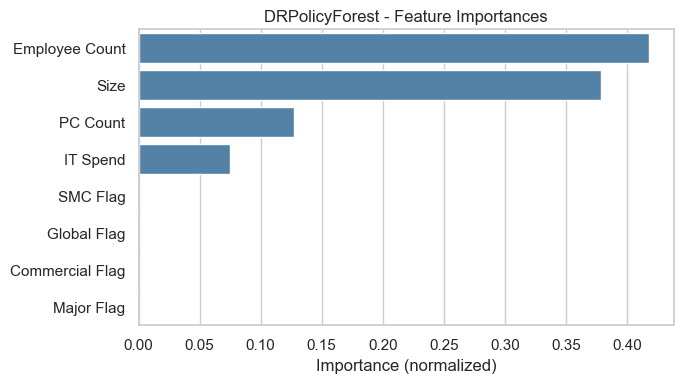

,feature,importance
0,Employee Count,0.417657
1,Size,0.378824
2,PC Count,0.127452
3,IT Spend,0.075229
4,SMC Flag,0.000479
5,Global Flag,0.000194
6,Commercial Flag,0.000147
7,Major Flag,0.000017


In [17]:
importances = dr_policy_forest.feature_importances_
fi_df = pd.DataFrame({
    'feature': covariates,
    'importance': importances,
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=fi_df, x='importance', y='feature', ax=ax, color='steelblue')
ax.set_title('DRPolicyForest - Feature Importances')
ax.set_xlabel('Importance (normalized)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig06_feature_importance.png', **SAVE_KW)
plt.show()

display(fi_df)


`Employee Count`(42%)와 `Size`(38%)가 전체 중요도의 약 80%를 차지하며, **고객 규모와 직원 수가 처치 배정을 주도하는 핵심 요인**임을 확인할 수 있습니다. `PC Count`(13%)와 `IT Spend`(8%)도 일부 기여하지만, Flag 변수들은 거의 영향을 미치지 않습니다. 이는 DRPolicyTree가 `Size`를 기준으로 분기했던 결과와도 일치합니다.

> **Q3 요약.** 세 정책 모두 "규모가 큰 고객 → 기술지원+할인, 그 외 → 주로 기술지원, 기대 순이익이 낮은 일부 → 처치 없음"라는 일관된 배정 패턴을 학습했습니다. 배정의 핵심 신호는 직원 수와 고객 규모입니다.

## Q4. 학습한 정책이 정말 더 나은가?

이제 학습한 정책들을 동일한 test set의 **AIPW score** 기준으로 비교합니다. 비교를 위해 모든 고객에게 동일한 처치를 적용하는 baseline 정책(`all_none`, `all_tech_support_only`, `all_discount_only`, `all_discount_plus_support`)도 함께 평가합니다.

학습된 정책의 value가 가장 좋은 baseline보다 높다면, **모두에게 동일한 처치를 적용하는 것보다 고객별 타겟팅이 더 효과적**이라는 의미입니다.

AIPW(Augmented Inverse Probability Weighting) score는 다음과 같이 정의합니다.

$$\hat\Gamma_{i,a} = \hat\mu_a(X_i) + \frac{\mathbf{1}[A_i=a]}{\hat e_a(X_i)}\bigl(Y_i^{net} - \hat\mu_a(X_i)\bigr)$$

- $\hat\mu_a(X_i)$: outcome model이 예측한 $E[Y^{net}(a)\mid X_i]$
- $\hat e_a(X_i)$: propensity model이 예측한 $P(A_i=a\mid X_i)$
- 두 번째 항: 실제 관측값과 예측값의 차이를 IPW로 보정

이 구조 덕분에 outcome model과 propensity model 중 **하나만 올바르게 추정되어도** 불편성이 유지됩니다. 이를 doubly robust(이중 견고성)라고 부릅니다.

In [18]:
Y_net_train = Y_net[train_idx]
Y_net_test  = Y_net[test_idx]

e_hat_net = np.clip(e_hat_raw, 0.02, 0.98)
e_hat_net = e_hat_net / e_hat_net.sum(axis=1, keepdims=True)

gamma_net = np.zeros((len(X_test), 4))
mu_hat_net = np.zeros((len(X_test), 4))

for treatment_id in range(4):
    outcome_model = RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    )
    outcome_model.fit(X_train[A_train == treatment_id], Y_net_train[A_train == treatment_id])
    mu_a = outcome_model.predict(X_test)
    observed_a = (A_test == treatment_id).astype(float)

    gamma_net[:, treatment_id] = mu_a + observed_a / e_hat_net[:, treatment_id] * (Y_net_test - mu_a)
    mu_hat_net[:, treatment_id] = mu_a


In [19]:
sample_ids = np.arange(5)

sample_prediction_table = pd.concat(
    {
        'sample': pd.DataFrame({
            'sample_id': sample_ids,
            'actual_treatment': pd.Series(A_test[sample_ids]).map(TREATMENT_NAMES).to_numpy(),
            'observed_net_outcome': Y_net_test[sample_ids],
        }),
        'e_hat': pd.DataFrame(e_hat_net[sample_ids], columns=TREATMENT_LABELS),
        'mu_hat': pd.DataFrame(mu_hat_net[sample_ids], columns=TREATMENT_LABELS),
        'gamma': pd.DataFrame(gamma_net[sample_ids], columns=TREATMENT_LABELS),
    },
    axis=1,
)

sample_prediction_table


sample                                                 e_hat  \
  sample_id       actual_treatment observed_net_outcome      none   
0         0  discount_plus_support          9254.558541  0.248633   
1         1      tech_support_only          7702.861662  0.211087   
2         2      tech_support_only          5062.184420  0.376570   
3         3                   none          8930.495022  0.339653   
4         4                   none          8156.575502  0.312265   

                                                               mu_hat  \
  tech_support_only discount_only discount_plus_support          none   
0          0.267338      0.272366              0.211662   5370.099281   
1          0.307204      0.243394              0.238315  10468.942522   
2          0.241901      0.256261              0.125268   2879.741786   
3          0.194701      0.246505              0.219142   8458.779217   
4          0.250021      0.312123              0.125590  10137.469821   

                                                                gamma  \
  tech_support_only discount_only discount_plus_support          none   
0       9559.777763   4547.484552           6984.731609   5370.099281   
1       6728.988419   8373.316633          11121.826609  10468.942522   
2       5449.409859    937.515103           2959.514347   2879.741786   
3       8254.372069   6054.598973           6560.028069   9847.598052   
4       3378.748035   5743.802939           2988.217314   3793.845054   

                                                         
  tech_support_only discount_only discount_plus_support  
0       9559.777763   4547.484552          17708.540116  
1       9899.108508   8373.316633          11121.826609  
2       3848.652052    937.515103           2959.514347  
3       8254.372069   6054.598973           6560.028069  
4       3378.748035   5743.802939           2988.217314

In [20]:
policy_assignments = {
    **{f'all_{treatment_name}': np.full(len(X_test), treatment_id) for treatment_id, treatment_name in TREATMENT_NAMES.items()},
    'plugin_drlearner_4treatment': pi_plugin,
    'dr_policy_tree_4treatment': pi_tree,
    'dr_policy_forest_4treatment': pi_forest,
}

# 원래 학습/평가 분할에서 계산한 정책 가치 점추정치
eval_rows = []
for policy_name, policy_assignment in policy_assignments.items():
    pi = np.asarray(policy_assignment).astype(int).ravel()
    scores = gamma_net[np.arange(len(pi)), pi]

    row = {
        'policy': policy_name,
        'value': scores.mean(),
    }
    for treatment_id, treatment_name in TREATMENT_NAMES.items():
        row[f'rate_{treatment_name}'] = np.mean(pi == treatment_id)
    eval_rows.append(row)

policy_eval = pd.DataFrame(eval_rows)
policy_eval.sort_values('value', ascending=False)



,policy,value,rate_none,rate_tech_support_only,rate_discount_only,rate_discount_plus_support
4,plugin_drlearner_4treatment,11797.813147,0.092,0.499,0.035,0.374
6,dr_policy_forest_4treatment,11619.027195,0.114,0.469,0.000,0.417
5,dr_policy_tree_4treatment,11148.549665,0.199,0.475,0.000,0.326
1,all_tech_support_only,10526.594766,0.000,1.000,0.000,0.000
3,all_discount_plus_support,10136.725288,0.000,0.000,0.000,1.000
2,all_discount_only,7545.092661,0.000,0.000,1.000,0.000
0,all_none,7249.345467,1.000,0.000,0.000,0.000


In [21]:
BOOT_PIPELINE_B = 100
BOOT_PIPELINE_SEED = 2026
BOOT_MODEL_TREES = 400

# 학습 포함 부트스트랩: 학습 데이터를 재표본추출하고, 정책과 보조 모델을 다시 학습한 뒤, 고정된 평가 데이터에서 평가
# 최종 평가 데이터 평균의 흔들림뿐 아니라 정책 학습 과정의 불확실성도 반영
def _aligned_predict_proba(model, X_eval, n_treatments=4):
    proba = model.predict_proba(X_eval)
    aligned = np.zeros((len(X_eval), n_treatments))
    for col_idx, treatment_id in enumerate(model.classes_):
        aligned[:, int(treatment_id)] = proba[:, col_idx]
    return aligned


def _make_rf_reg(seed, n_estimators=BOOT_MODEL_TREES):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        min_samples_leaf=20,
        random_state=seed,
        n_jobs=1,
    )


def _make_rf_clf(seed, n_estimators=BOOT_MODEL_TREES):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        min_samples_leaf=20,
        random_state=seed,
        n_jobs=1,
    )


def _aipw_gamma_from_bootstrap_train(X_b, A_b, Y_b, seed):
    prop_model = _make_rf_clf(seed)
    prop_model.fit(X_b, A_b)
    e_hat = np.clip(_aligned_predict_proba(prop_model, X_test), 0.02, 0.98)
    e_hat = e_hat / e_hat.sum(axis=1, keepdims=True)

    gamma = np.zeros((len(X_test), 4))
    for treatment_id in range(4):
        mask = A_b == treatment_id
        outcome_model = _make_rf_reg(seed + 100 + treatment_id)
        outcome_model.fit(X_b[mask], Y_b[mask])
        mu_a = outcome_model.predict(X_test)
        observed_a = (A_test == treatment_id).astype(float)
        gamma[:, treatment_id] = mu_a + observed_a / e_hat[:, treatment_id] * (Y_net_test - mu_a)
    return gamma


def _fit_bootstrap_policies(X_b, A_b, Y_b, seed):
    dr_cate_b = DRLearner(
        model_regression=_make_rf_reg(seed + 10),
        model_propensity=_make_rf_clf(seed + 20),
        model_final=_make_rf_reg(seed + 30, n_estimators=300),
        categories=[0, 1, 2, 3],
        min_propensity=0.02,
        cv=3,
        random_state=seed,
    )
    dr_cate_b.fit(Y_b, A_b, X=X_b)
    cate_vs_none_b = dr_cate_b.const_marginal_effect(X_test)
    pi_plugin_b = np.argmax(np.column_stack([np.zeros(len(X_test)), cate_vs_none_b]), axis=1)

    dr_policy_tree_b = DRPolicyTree(
        max_depth=2,
        min_samples_leaf=30,
        model_regression=_make_rf_reg(seed + 40),
        model_propensity=_make_rf_clf(seed + 50),
        categories=[0, 1, 2, 3],
        min_propensity=0.02,
        cv=3,
        random_state=seed,
    )
    dr_policy_tree_b.fit(Y_b, A_b, X=X_b)
    pi_tree_b = dr_policy_tree_b.predict(X_test).astype(int).ravel()

    dr_policy_forest_b = DRPolicyForest(
        n_estimators=BOOT_MODEL_TREES,
        max_depth=5,
        min_samples_leaf=30,
        model_regression=_make_rf_reg(seed + 60),
        model_propensity=_make_rf_clf(seed + 70),
        categories=[0, 1, 2, 3],
        min_propensity=0.02,
        cv=3,
        random_state=seed,
        n_jobs=1,
    )
    dr_policy_forest_b.fit(Y_b, A_b, X=X_b)
    pi_forest_b = dr_policy_forest_b.predict(X_test).astype(int).ravel()

    return {
        **{f'all_{treatment_name}': np.full(len(X_test), treatment_id) for treatment_id, treatment_name in TREATMENT_NAMES.items()},
        'plugin_drlearner_4treatment': pi_plugin_b,
        'dr_policy_tree_4treatment': pi_tree_b,
        'dr_policy_forest_4treatment': pi_forest_b,
    }


boot_rng = np.random.default_rng(BOOT_PIPELINE_SEED)
bootstrap_values = []

for b in range(BOOT_PIPELINE_B):
    boot_pos = boot_rng.integers(0, len(X_train), size=len(X_train))
    X_b = X_train[boot_pos]
    A_b = A_train[boot_pos]
    Y_b = Y_net_train[boot_pos]

    # n=1,000에서는 거의 발생하지 않지만, 네 처치가 모두 포함되는지 명시적으로 확인
    if len(np.unique(A_b)) < 4:
        continue

    seed_b = BOOT_PIPELINE_SEED + b
    gamma_b = _aipw_gamma_from_bootstrap_train(X_b, A_b, Y_b, seed_b)
    policies_b = _fit_bootstrap_policies(X_b, A_b, Y_b, seed_b)

    for policy_name, pi_b in policies_b.items():
        pi_b = np.asarray(pi_b).astype(int).ravel()
        bootstrap_values.append({
            'bootstrap_iter': b,
            'policy': policy_name,
            'value': gamma_b[np.arange(len(pi_b)), pi_b].mean(),
        })

    if (b + 1) % 10 == 0:
        print(f'completed {b + 1}/{BOOT_PIPELINE_B} bootstrap refits')

policy_bootstrap = pd.DataFrame(bootstrap_values)
policy_bootstrap_summary = (
    policy_bootstrap
    .groupby('policy')['value']
    .agg(
        bootstrap_mean='mean',
        bootstrap_se='std',
        ci_lower=lambda s: np.percentile(s, 2.5),
        ci_upper=lambda s: np.percentile(s, 97.5),
        n_boot='count',
    )
    .reset_index()
)

policy_eval = policy_eval.drop(columns=[c for c in ['ci_lower', 'ci_upper', 'value_se'] if c in policy_eval.columns])
policy_eval = policy_eval.merge(policy_bootstrap_summary, on='policy', how='left')

display_cols = [
    'policy', 'value', 'bootstrap_mean', 'bootstrap_se', 'ci_lower', 'ci_upper', 'n_boot',
] + [f'rate_{n}' for n in TREATMENT_LABELS]
policy_eval.sort_values('value', ascending=False)[display_cols]




completed 10/100 bootstrap refits


completed 20/100 bootstrap refits


completed 30/100 bootstrap refits


completed 40/100 bootstrap refits


completed 50/100 bootstrap refits


...

completed 70/100 bootstrap refits


completed 80/100 bootstrap refits


completed 90/100 bootstrap refits


completed 100/100 bootstrap refits


,policy,value,bootstrap_mean,bootstrap_se,ci_lower,ci_upper,n_boot,rate_none,rate_tech_support_only,rate_discount_only,rate_discount_plus_support
4,plugin_drlearner_4treatment,11797.813147,11694.944683,139.220184,11463.704488,11984.257635,100,0.092,0.499,0.035,0.374
6,dr_policy_forest_4treatment,11619.027195,11629.203247,124.639273,11364.010556,11907.003712,100,0.114,0.469,0.000,0.417
5,dr_policy_tree_4treatment,11148.549665,11617.171655,221.947675,11055.885199,11922.928523,100,0.199,0.475,0.000,0.326
1,all_tech_support_only,10526.594766,10547.001638,142.275247,10315.938464,10869.561899,100,0.000,1.000,0.000,0.000
3,all_discount_plus_support,10136.725288,10161.410133,122.487504,9894.824702,10387.778277,100,0.000,0.000,0.000,1.000
2,all_discount_only,7545.092661,7571.298533,113.847796,7365.956062,7778.166203,100,0.000,0.000,1.000,0.000
0,all_none,7249.345467,7259.428806,66.939144,7133.288793,7391.958950,100,1.000,0.000,0.000,0.000


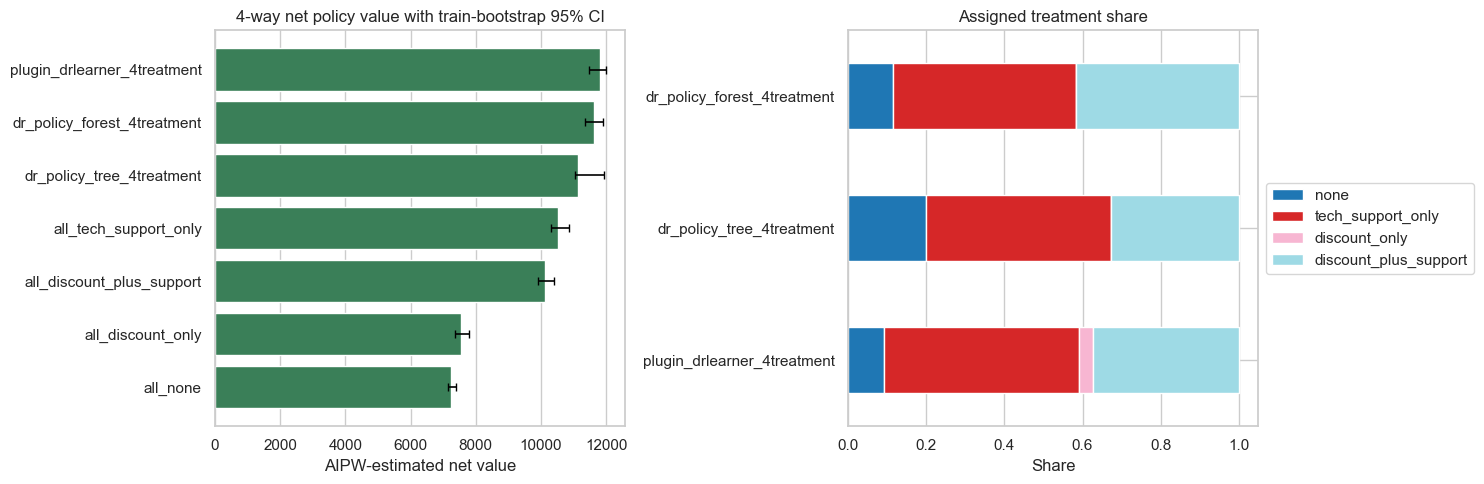

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = policy_eval.sort_values('value', ascending=False).reset_index(drop=True)
sns.barplot(data=plot_df, x='value', y='policy', ax=axes[0], color='seagreen')

xerr = np.vstack([
    plot_df['value'] - plot_df['ci_lower'],
    plot_df['ci_upper'] - plot_df['value'],
])
axes[0].errorbar(
    x=plot_df['value'],
    y=np.arange(len(plot_df)),
    xerr=xerr,
    fmt='none',
    ecolor='black',
    elinewidth=1.2,
    capsize=3,
)
axes[0].set_title('4-way net policy value with train-bootstrap 95% CI')
axes[0].set_xlabel('AIPW-estimated net value')
axes[0].set_ylabel('')

treatment_rate_cols = [f'rate_{name}' for name in TREATMENT_LABELS]
rate_df = policy_eval.set_index('policy')[treatment_rate_cols]
rate_df.columns = TREATMENT_LABELS
rate_df.loc[['plugin_drlearner_4treatment', 'dr_policy_tree_4treatment', 'dr_policy_forest_4treatment']].plot(kind='barh', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Assigned treatment share')
axes[1].set_xlabel('Share')
axes[1].set_ylabel('')
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(FIGDIR / 'fig07_policy_value.png', **SAVE_KW)
plt.show()



세 학습 정책 모두 단일 처치 정책보다 높은 가치를 가집니다. **고객별로 처치를 다르게 배정하는 것이 모두에게 같은 처치를 적용하는 것보다 효과적**이라는 의미입니다.

- 학습 정책: DRLearner plug-in(**11,798**) > DRPolicyForest(11,619) > DRPolicyTree(11,149)
- 단일 처치: `all_tech_support_only`(10,527) > `all_discount_plus_support`(10,137) > `all_discount_only`(7,545) > `all_none`(7,249)

신뢰구간은 train set을 100번 재표본추출하고, 매번 정책과 AIPW 평가용 nuisance model을 다시 학습한 뒤 같은 test set에서 평가하는 **학습 포함 bootstrap percentile CI**로 계산했습니다. plug-in과 forest는 신뢰구간이 상당 부분 겹쳐 실질적 차이가 있다고 보기는 어렵습니다. tree 정책은 해석 가능한 구조를 유지하는 대신 성능을 일부 양보했습니다. `all_discount_plus_support`가 `all_tech_support_only`보다 낮은 이유는, 할인 비용이 고객 규모에 따라 커지도록 설정해 일부 고객에서 할인의 순수익이 비용을 상쇄하지 못했기 때문입니다.

> **Q4 요약.** 세 학습 정책 모두 최선의 단일 처치 정책보다 높은 순이익을 냅니다(plug-in 기준 +12%, 처치 없음 대비 +63%). 타겟팅의 가치가 데이터로 확인됩니다.



## Q5. 예산이 제한되면 어떤 정책이 유리한가?

지금까지는 어떤 정책이 전체적으로 더 높은 AIPW value를 갖는지 비교했습니다. 그러나 실제로는 예산이 제한되어 있을 수 있습니다. 같은 예산 안에서 어떤 정책이 더 효율적인지 비교하려면 **비용 곡선(cost curve)**이 유용합니다.

먼저 고객별 기대 비용 $E[C(a) \mid X_i]$를 추정합니다. 실제 비용은 해당 고객이 받은 처치에서만 관측되므로, 처치별로 훈련 데이터에서 비용 회귀 모델을 학습해 test set에 적용합니다.

In [23]:
# 처치별 E[C(a) | X] 추정
# c_hat_test[i, a] = 고객 i가 처치 a를 받을 때의 예측 비용
c_true_by_treatment = {1: c_tech, 2: c_disc, 3: c_tech + c_disc}

c_hat_test = np.zeros((len(X_test), 4))   # 처치 0 → 비용 = 0
for treatment_id in [1, 2, 3]:
    mask_train = (A_train == treatment_id)
    mdl = RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                                random_state=SEED, n_jobs=1)
    mdl.fit(X_train[mask_train], c_true_by_treatment[treatment_id][train_idx[mask_train]])
    c_hat_test[:, treatment_id] = np.maximum(mdl.predict(X_test), 200.0)

print("Estimated E[C(a)|X] - test set (mean +/- std):")
for treatment_id, treatment_name in TREATMENT_NAMES.items():
    if treatment_id > 0:
        print(f"  {treatment_name:25s}: {c_hat_test[:, treatment_id].mean():8,.0f} +/- {c_hat_test[:, treatment_id].std():6,.0f}")


Estimated E[C(a)|X] - test set (mean +/- std):
  tech_support_only        :    4,892 +/-  3,466
  discount_only            :    5,454 +/-  2,330
  discount_plus_support    :   10,687 +/-  4,139


### 비용 모델 검증

비용 곡선의 x축은 참값이 아니라 train set으로 학습한 모델의 **예측 비용**(`c_hat_test`)입니다. 따라서 곡선을 신뢰하려면 예측 비용이 실제 비용과 얼마나 일치하는지 확인해야 합니다. 이 시뮬레이션에서는 모든 고객의 참값 비용을 알 수 있으므로, test set에서 처치별로 예측 vs 참값을 R²·MAE·평균 편향으로 비교합니다.

,treatment,R2,MAE,mean_true,mean_pred,bias_%
0,tech_support_only,0.562196,1491.690752,4858.962599,4892.094944,0.681881
1,discount_only,0.450900,1705.854016,5837.758769,5454.461984,-6.565821
2,discount_plus_support,0.586309,2325.303838,10696.721367,10687.401040,-0.087133


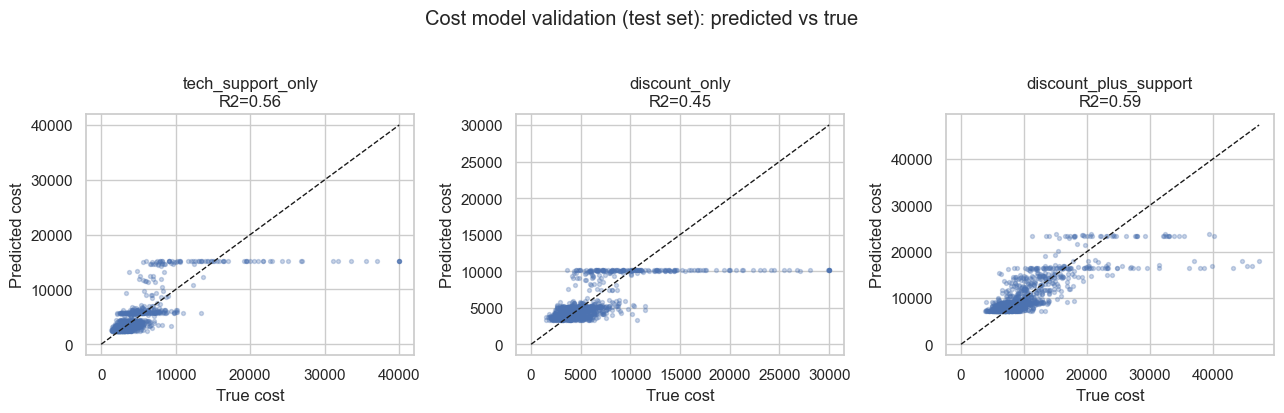

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error

cost_eval_rows = []
for treatment_id, treatment_name in [(1, 'tech_support_only'), (2, 'discount_only'), (3, 'discount_plus_support')]:
    truth = c_true_by_treatment[treatment_id][test_idx]   # 평가 데이터의 참값 비용
    pred  = c_hat_test[:, treatment_id]                    # 평가 데이터의 예측 비용
    cost_eval_rows.append({
        'treatment': treatment_name,
        'R2':        r2_score(truth, pred),
        'MAE':       mean_absolute_error(truth, pred),
        'mean_true': truth.mean(),
        'mean_pred': pred.mean(),
        'bias_%':    100 * (pred.mean() - truth.mean()) / truth.mean(),
    })
display(pd.DataFrame(cost_eval_rows))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (treatment_id, treatment_name) in zip(axes, [(1, 'tech_support_only'), (2, 'discount_only'), (3, 'discount_plus_support')]):
    truth = c_true_by_treatment[treatment_id][test_idx]
    pred  = c_hat_test[:, treatment_id]
    ax.scatter(truth, pred, s=8, alpha=0.3)
    lim = [0, max(truth.max(), pred.max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_title(f'{treatment_name}\nR2={r2_score(truth, pred):.2f}')
    ax.set_xlabel('True cost')
    ax.set_ylabel('Predicted cost')
plt.suptitle('Cost model validation (test set): predicted vs true', y=1.03)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig09_cost_validation.png', **SAVE_KW)
plt.show()


평균 편향은 −6.6% ~ +0.7%로 작아, **집계(평균) 수준에서는 예측 비용이 참값을 잘 따라갑니다.** 비용 곡선의 x축은 누적 비용 합계이므로 곡선 위치와 예산 구간별 비교 결론은 신뢰할 만합니다. 다만 개별 고객 단위 정확도는 R² 0.45~0.59로 보통 수준이라, 순이익/비용 가성비 정렬에는 일부 노이즈가 섞일 수 있습니다.

비용 곡선은 모두 test set에서 그립니다. 처치 대상 고객을 **순이익/예상 비용** 비율이 높은 순서로 차례로 더해 가며, 두 축은 다음과 같습니다.

- **x축**: 누적 처치 비용 합계 ($, gross)
- **y축**: 누적 순이익 증분 합계 ($, net — 처치 없음 대비, 비용 차감 후)

$x = B$에서 세로선을 그으면 예산 $B$ 하의 정책 비교가 됩니다. 같은 예산에서 y값이 높을수록 더 효율적인 정책입니다. 곡선의 종점(●)은 처치 대상 전원을 처치했을 때의 위치입니다.

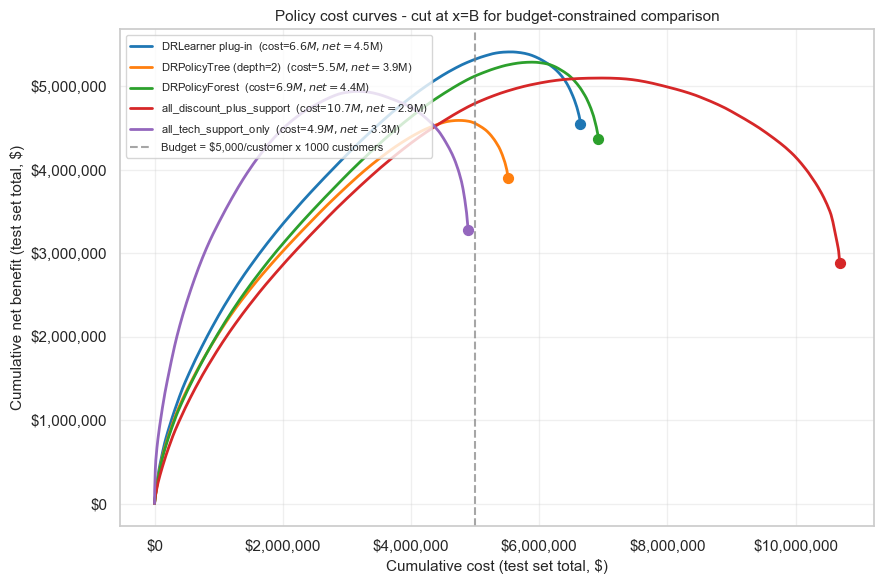

In [25]:
import matplotlib.ticker as mtick

def policy_cost_curve(pi_eval, gamma_matrix, c_hat_matrix):
    # 순이익/비용 비율 내림차순으로 처치 고객을 정렬해 누적 합계를 반환
    pi = np.asarray(pi_eval).ravel().astype(int)
    n = len(pi)
    treated = pi > 0
    if treated.sum() == 0:
        return np.array([0.0]), np.array([0.0])

    benefit = gamma_matrix[np.arange(n), pi] - gamma_matrix[:, 0]
    cost    = c_hat_matrix[np.arange(n), pi].astype(float)

    b_t, c_t = benefit[treated], cost[treated]
    ratio = np.where(c_t > 0, b_t / c_t, b_t)
    order = np.argsort(-ratio)

    cum_cost    = np.r_[0, np.cumsum(c_t[order])]   # 누적 합계 (나누지 않음)
    cum_benefit = np.r_[0, np.cumsum(b_t[order])]
    return cum_cost, cum_benefit


n_test = len(X_test)
policies_curve = [
    ('DRLearner plug-in',         pi_plugin),
    ('DRPolicyTree (depth=2)',     pi_tree),
    ('DRPolicyForest',            pi_forest),
    ('all_discount_plus_support', np.full(n_test, 3)),
    ('all_tech_support_only',     np.full(n_test, 1)),
]

dollar = mtick.FuncFormatter(lambda v, _: f'${v:,.0f}')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for (name, pi_eval), color in zip(policies_curve, colors):
    cc, cg = policy_cost_curve(pi_eval, gamma_net, c_hat_test)
    ax.plot(cc, cg, lw=2, color=color,
            label=f'{name}  (cost=${cc[-1]/1e6:.1f}M, net=${cg[-1]/1e6:.1f}M)')
    ax.scatter([cc[-1]], [cg[-1]], s=50, color=color, zorder=5)

budget_example = 5_000 * n_test
ax.axvline(budget_example, color='gray', lw=1.5, ls='--', alpha=0.7,
           label=f'Budget = $5,000/customer x {n_test} customers')

ax.xaxis.set_major_formatter(dollar)
ax.yaxis.set_major_formatter(dollar)
ax.set_xlabel('Cumulative cost (test set total, $)', fontsize=11)
ax.set_ylabel('Cumulative net benefit (test set total, $)', fontsize=11)
ax.set_title('Policy cost curves - cut at x=B for budget-constrained comparison', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig08_cost_curve.png', **SAVE_KW)
plt.show()


순수익/비용 비율로 정렬하는 이유와 예산 구간별 결과를 함께 살펴봅니다.

#### 왜 순수익만으로 정렬하면 안 되는가?

예산이 제한되어 있을 때는 **"같은 예산으로 최대 순수익"**을 얻어야 합니다. 예를 들어:

- **A 고객사**: 순수익 $10,000, 비용 $100,000
- **B 고객사**: 순수익 $3,000, 비용 $5,000

순수익만 보면 A가 크지만, 예산이 $10,000밖에 없다면 **A는 처치조차 할 수 없습니다.** B를 처치하면 $5,000을 써서 $3,000 순수익을 얻을 수 있습니다. 비율로 보면 A는 0.10, B는 0.60으로 B가 훨씬 효율적입니다. 따라서 예산 제약 하에서는 **순수익/비용 비율이 높은 고객부터 처치**해야 같은 예산으로 더 많은 순수익을 얻을 수 있습니다.

#### 예산 구간별 최적 정책

**소액 예산 ($3.9M 이하):** `all_tech_support_only`가 가장 효율적입니다. 기술지원 평균 비용이 낮아 순수익/비용 비율이 높은 고객부터 빠르게 처치할 수 있기 때문입니다.

**중간 예산 ($3.9M~$6M):** 학습 정책(plug-in, forest)이 앞서기 시작합니다. plug-in이 `all_tech_support_only`를 앞서기 시작하는 시점은 약 **$3.9M**입니다.

**예산 전부 소진:** 학습 정책이 가장 효율적입니다.

| 정책 | 총 비용 | 총 순이익 |
| --- | --: | --: |
| DRLearner plug-in | $6.6M | $4.6M |
| DRPolicyForest | $6.9M | $4.4M |
| DRPolicyTree (depth=2) | $5.5M | $3.9M |
| all\_tech\_support\_only | $4.9M | $3.3M |
| all\_discount\_plus\_support | $10.7M | $2.9M |

`all_discount_plus_support`는 $10.7M을 전부 소진해도 순이익이 $2.9M에 그칩니다. 할인 비용이 고객 규모에 따라 커지도록 설정해 일부 고객에서 할인의 순수익이 비용을 상쇄하지 못했기 때문입니다.

> **Q5 요약.** "어떤 정책이 최선인가"는 예산에 의존합니다. 예산이 매우 적으면 저비용 단일 처치가, 예산이 충분하면 타겟팅 정책이 유리합니다. 비용 곡선은 예산 의사결정에 직접 활용할 수 있는 도구입니다.

## 결론 및 제언

**분석 요약.** 약 2,000곳의 관찰 데이터에서, 비용을 반영한 순이익을 기준으로 4가지 프로모션의 고객별 최적 배정을 학습했습니다. 처치 효과의 이질성을 진단(Q1)하고 인과 식별 가정을 점검(Q2)한 뒤, 세 가지 정책을 학습(Q3)하고 학습/평가 데이터를 분리해 doubly robust(AIPW) 기준으로 가치를 비교(Q4)했으며, 예산 제약 하의 효율(Q5)까지 평가했습니다.

**비즈니스 제언.**

1. **모두에게 동일한 프로모션을 주지 말고, 타겟팅하라.** 고객별 타겟팅은 최선의 단일 처치 대비 약 12%, 처치 없음 대비 약 63% 높은 순이익을 냅니다.
2. **배정 기준은 고객 규모와 직원 수다.** 규모가 큰 고객에게는 *기술지원+할인*, 그 외 고객에게는 주로 *기술지원*을, 기대 순이익이 낮은 일부에게는 *처치 없음*를 권합니다.
3. **예산에 맞춰 정책을 선택하라.** 예산이 빠듯하면 저비용 *전원 기술지원*이 효율적이고, 예산이 고객사당 \$4,000을 넘어가면 학습 정책으로 전환하는 것이 유리합니다.
4. **운영 환경에 맞는 모델을 골라라.** 성능 최우선이면 plug-in/forest를, 이해관계자 설명·공정성 검토·운영 안정성이 중요하면 약간의 성능을 양보하더라도 해석 가능한 **depth=2 트리 정책**을 권합니다.

**한계와 다음 단계.**

- 비용은 실제 데이터가 아니라 **시뮬레이션** 값입니다. 실제 비용 데이터가 확보되면 결론이 달라질 수 있습니다.
- Unconfoundedness는 검정 불가능한 가정입니다. 가능하다면 소규모 **무작위 실험(RCT)**으로 학습된 정책을 검증하는 것이 이상적입니다.
- 표본이 약 1,000곳(test) 수준이고 학습 포함 bootstrap에서도 정책 간 신뢰구간이 겹칩니다. 표본을 늘리면 정책 선택의 확신도가 높아집니다.
- 현재 bootstrap은 train set 재표본추출 후 정책과 nuisance model을 다시 학습하고, 고정된 test set에서 평가하는 방식입니다. 평가 대상 모집단 자체의 변동까지 보려면 반복 split이나 외부 검증 데이터가 추가로 필요합니다.
- 운영 적용 이후에는 시간에 따른 정책 성과 모니터링과 A/B 테스트 기반 검증을 제안합니다.



## 참고 자료

이 분석은 Athey & Wager (2021)와 Stanford ML+CI Tutorial을 주요 참고 자료로 작성되었습니다.

- **Athey, S., & Wager, S. (2021).** Policy Learning with Observational Data. *Econometrica.* [arxiv.org/abs/1702.02896](https://arxiv.org/abs/1702.02896)
- **Sun, L., Du, X., Wager, S., et al. (2021).** Treatment Allocation under Uncertain Costs. [arxiv.org/abs/2103.11066](https://arxiv.org/abs/2103.11066)
- **Imai, K., & Li, M. L. (2019).** Experimental Evaluation of Individualized Treatment Rules. [arxiv.org/pdf/1905.05389.pdf](https://arxiv.org/pdf/1905.05389.pdf)
- **Stanford ML+CI Tutorial — Policy Learning I (Binary Treatment).** [bookdown.org/.../policy-learning-i---binary-treatment.html](https://bookdown.org/stanfordgsbsilab/ml-ci-tutorial/policy-learning-i---binary-treatment.html)